In [1]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


In [2]:
import os, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import open_clip
import matplotlib.pyplot as plt

SEED          = 42          
TRAIN_CSV     = '/kaggle/input/datasets/pravinkumarv45510/dataset-analysis/data/train.csv'
EPOCHS        = 10
BATCH_SIZE    = 64        
LR            = 1e-5
TEMPERATURE   = 0.07
UNFREEZE_LAST = 4        
CHECKPOINT_DIR = 'clip_finetuning_results'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
class FashionPairDataset(Dataset):
    def __init__(self, csv_path, transform, min_imgs=2):
        df = pd.read_csv(csv_path)
        counts = df.groupby('item_id')['image_path'].count()
        
        valid_items = counts[counts >= min_imgs].index
        df = df[df['item_id'].isin(valid_items)].reset_index(drop=True)
        
        self.item2paths = df.groupby('item_id')['full_path'].apply(list).to_dict()
        self.items      = list(self.item2paths.keys())
        self.transform  = transform
        print(f"Dataset: {len(df):,} images and {len(self.items):,} valid items")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item   = self.items[idx]
        paths  = self.item2paths[item]
        anchor_path, pos_path = random.sample(paths, 2)
        anchor = self.transform(Image.open(anchor_path).convert('RGB'))
        pos    = self.transform(Image.open(pos_path).convert('RGB'))
        return anchor, pos

In [4]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai')
clip_model = clip_model.to(DEVICE)

train_dataset = FashionPairDataset(TRAIN_CSV, preprocess)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=4, pin_memory=True, drop_last=True)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Dataset: 25,870 images and 3,985 valid items


In [5]:
def set_trainable_params(model, unfreeze_last_n: int):
    # Freeze all
    for p in model.parameters():
        p.requires_grad = False

    visual_blocks = model.visual.transformer.resblocks
    total_blocks  = len(visual_blocks)
    for i in range(total_blocks - unfreeze_last_n, total_blocks):
        for p in visual_blocks[i].parameters():
            p.requires_grad = True

    if hasattr(model.visual, 'proj') and model.visual.proj is not None:
        model.visual.proj.requires_grad = True

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {n_train:,} / {n_total:,} ({100*n_train/n_total:.1f}%)")

set_trainable_params(clip_model, UNFREEZE_LAST)

Trainable params: 28,744,704 / 151,277,313 (19.0%)


## 4. Contrastive Loss (InfoNCE)

In [6]:
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_a: torch.Tensor, z_p: torch.Tensor) -> torch.Tensor:
        z_a = F.normalize(z_a, dim=-1)
        z_p = F.normalize(z_p, dim=-1)

        logits = torch.matmul(z_a, z_p.T) / self.temperature
        labels = torch.arange(logits.size(0), device=logits.device)
        loss_a = F.cross_entropy(logits, labels)
        loss_p = F.cross_entropy(logits.T, labels)
        return (loss_a + loss_p) / 2

loss_fn = InfoNCELoss(temperature=TEMPERATURE)

In [7]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clip_model.parameters()),
    lr=LR, weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': []}
best_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    clip_model.train()
    epoch_loss = 0.0

    for anchor, positive in tqdm(train_loader,
                                  desc=f"Epoch {epoch}/{EPOCHS}",
                                  leave=False):
        anchor   = anchor.to(DEVICE)
        positive = positive.to(DEVICE)

        z_a = clip_model.encode_image(anchor)
        z_p = clip_model.encode_image(positive)

        loss = loss_fn(z_a, z_p)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, clip_model.parameters()), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        ckpt_path = os.path.join(CHECKPOINT_DIR, 'clip_finetuned_best.pt')
        torch.save({
            'epoch': epoch,
            'model_state': clip_model.visual.state_dict(),
            'loss': avg_loss
        }, ckpt_path)
        print(f"   ✓ Best checkpoint saved (loss={avg_loss:.4f})")

Epoch   1 | Loss: 0.6618 | LR: 9.76e-06
   ✓ Best checkpoint saved (loss=0.6618)


Epoch   2 | Loss: 0.2787 | LR: 9.05e-06
   ✓ Best checkpoint saved (loss=0.2787)


Epoch   3 | Loss: 0.2288 | LR: 7.94e-06
   ✓ Best checkpoint saved (loss=0.2288)


Epoch   4 | Loss: 0.1938 | LR: 6.55e-06
   ✓ Best checkpoint saved (loss=0.1938)


Epoch   5 | Loss: 0.1692 | LR: 5.00e-06
   ✓ Best checkpoint saved (loss=0.1692)


Epoch   6 | Loss: 0.1487 | LR: 3.45e-06
   ✓ Best checkpoint saved (loss=0.1487)


Epoch   7 | Loss: 0.1489 | LR: 2.06e-06


Epoch   8 | Loss: 0.1426 | LR: 9.55e-07
   ✓ Best checkpoint saved (loss=0.1426)


Epoch   9 | Loss: 0.1301 | LR: 2.45e-07
   ✓ Best checkpoint saved (loss=0.1301)


Epoch  10 | Loss: 0.1205 | LR: 0.00e+00
   ✓ Best checkpoint saved (loss=0.1205)


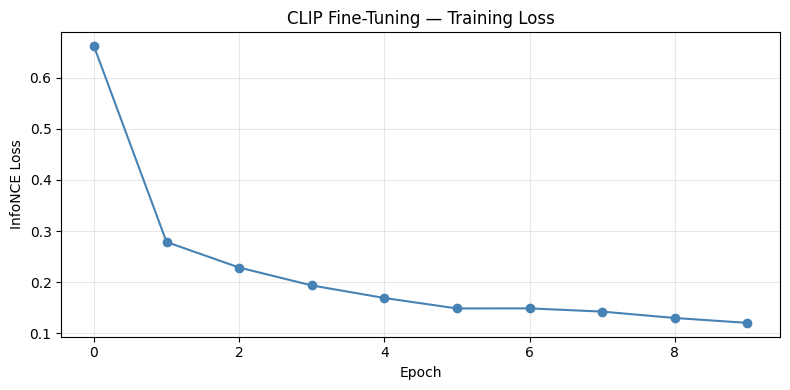

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], marker='o', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('CLIP Fine-Tuning — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'loss_curve.png'), dpi=120)
plt.show()

In [9]:
full_ckpt_path = os.path.join(CHECKPOINT_DIR, 'clip_finetuned_full.pt')
torch.save(clip_model.state_dict(), full_ckpt_path)
print(f"Full model saved → {full_ckpt_path}")

Full model saved → clip_finetuning_results/clip_finetuned_full.pt
